# House Prices - Advanced Regression Techniques
## MLflow Experiment Tracking with DagsHub

## Setup & Imports

In [ ]:
!pip install dagshub mlflow -q

import os
import numpy as np
import pandas as pd
import mlflow

DAGSHUB_USER  = "ekatsirekidze"
DAGSHUB_REPO  = "ML_HW1"
DAGSHUB_TOKEN = "your_token_here"

os.environ["MLFLOW_TRACKING_URI"]      = f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USER
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

mlflow.set_experiment("house-prices")
print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment   :", mlflow.get_experiment_by_name("house-prices").experiment_id)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

## 1. Data Loading & EDA


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n")
print(df.dtypes.to_string())

Shape: (1460, 81)

Column dtypes:

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF    

In [4]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")

Numerical columns (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',

In [5]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [6]:
for col in categorical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).to_string())


--- MSZoning (5 unique) ---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10

--- Street (2 unique) ---
Street
Pave    1454
Grvl       6

--- Alley (2 unique) ---
Alley
NaN     1369
Grvl      50
Pave      41

--- LotShape (4 unique) ---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10

--- LandContour (4 unique) ---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36

--- Utilities (2 unique) ---
Utilities
AllPub    1459
NoSeWa       1

--- LotConfig (5 unique) ---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4

--- LandSlope (3 unique) ---
LandSlope
Gtl    1382
Mod      65
Sev      13

--- Neighborhood (25 unique) ---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU    

### Missing Values Analysis


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_df

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


## 2. Cleaning 

### Drop columns that cannot be used for prediction

**Id** — a row identifier, carries zero signal about house price.

**Utilities** — nearly all values are `AllPub` (1457/1460). Zero variance → useless for prediction.

**Street** — 99.6 % `Pave`, essentially constant.

**PoolQC, Alley, MiscFeature** — 94–99 % missing. Too sparse to be reliable.

**Fence** — 80.75 % missing, but whether a house *has* a fence is meaningful even without quality detail. We extract a binary `HasFence` flag before dropping the original.

**MiscVal** — dollar value of misc features; extreme skew and low coverage.

In [8]:
df['HasFence'] = df['Fence'].notna().astype(int)
print("HasFence value counts:", df['HasFence'].value_counts().to_dict())

drop_cols = ['Id', 'Utilities', 'Street', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MiscVal']
df = df.drop(columns=drop_cols)
print(f"\nRemaining columns: {df.shape[1]}")
print(df.columns.tolist())

HasFence value counts: {0: 1179, 1: 281}

Remaining columns: 74
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPo

### Impute remaining missing values

For **categorical** columns, NA often genuinely means "None" (e.g. no fireplace → `FireplaceQu` is NA). Fill with `'None'`.

For **numerical** columns, use the **median** — robust to skew which is common in housing data.

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice']

for col in cat_cols:
    df[col] = df[col].fillna('None')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing after imputation:", df.isnull().sum().sum())

Missing after imputation: 0


## 3. Feature Engineering

Year-based columns contain real calendar years which are hard for a model to interpret directly. Converting them to **age** (relative to year sold) gives the model a linear scale to work with.

In [10]:
df['HouseAge']    = df['YrSold'] - df['YearBuilt']
df['RemodAge']    = df['YrSold'] - df['YearRemodAdd']
df['GarageAge']   = df['YrSold'] - df['GarageYrBlt']
df['TotalBath']   = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
df['TotalSF']     = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalPorchSF']= df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']

df[['HouseAge', 'RemodAge', 'GarageAge', 'TotalBath', 'TotalSF', 'TotalPorchSF']].describe()

,HouseAge,RemodAge,GarageAge,TotalBath,TotalSF,TotalPorchSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,36.547945,22.950000,29.226712,2.210616,2567.048630,181.329452
std,30.250152,20.640653,24.034844,0.785399,821.714421,156.656097
min,0.000000,-1.000000,0.000000,1.000000,334.000000,0.000000
25%,8.000000,4.000000,7.000000,2.000000,2009.500000,45.000000
50%,35.000000,14.000000,28.000000,2.000000,2474.000000,164.000000
75%,54.000000,41.000000,46.000000,2.500000,3004.000000,266.000000
max,136.000000,60.000000,107.000000,6.000000,11752.000000,1027.000000


In [11]:
year_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold']
df = df.drop(columns=year_cols)
print(f"Shape after dropping raw year columns: {df.shape}")

Shape after dropping raw year columns: (1460, 75)


### Encode ordinal quality features

Several columns use a clear rating scale (`Ex > Gd > TA > Fa > Po > None`). Encoding these as integers preserves their natural ordering instead of exploding them into dummies.

In [12]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                     'HeatingQC', 'KitchenQual', 'FireplaceQu',
                     'GarageQual', 'GarageCond']

for col in ordinal_qual_cols:
    df[col] = df[col].map(quality_map)

finish_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df['BsmtFinType1'] = df['BsmtFinType1'].map(finish_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(finish_map)

df['GarageFinish'] = df['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
df['BsmtExposure'] = df['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
df['Functional']   = df['Functional'].map({'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3,
                                            'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7})
df['LandSlope']    = df['LandSlope'].map({'Sev': 0, 'Mod': 1, 'Gtl': 2})
df['PavedDrive']   = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
df['CentralAir']   = df['CentralAir'].map({'N': 0, 'Y': 1})

print("Ordinal encoding done")
df[ordinal_qual_cols + ['BsmtFinType1', 'BsmtFinType2', 'GarageFinish',
                         'BsmtExposure', 'Functional', 'LandSlope',
                         'PavedDrive', 'CentralAir']].head()

Ordinal encoding done


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,BsmtFinType1,BsmtFinType2,GarageFinish,BsmtExposure,Functional,LandSlope,PavedDrive,CentralAir
0,4,3,4,3,5,4,0,3,3,6,1,2,1,7,2,2,1
1,3,3,4,3,5,3,3,3,3,5,1,2,4,7,2,2,1
2,4,3,4,3,5,4,3,3,3,6,1,2,2,7,2,2,1
3,3,3,3,4,4,4,4,3,3,5,1,1,1,7,2,2,1
4,4,3,4,3,5,4,3,3,3,6,1,2,3,7,2,2,1


### One-Hot Encode remaining categorical features

Remaining string columns have no natural order, so we use `OneHotEncoder`. We drop the first dummy per column to avoid multicollinearity.

In [13]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

remaining_cat = df.select_dtypes(include='object').columns.tolist()
print(f"Columns to one-hot encode ({len(remaining_cat)}):\n{remaining_cat}")

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(df[remaining_cat])
ohe_cols  = ohe.get_feature_names_out(remaining_cat)

df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
df = pd.concat([df.drop(columns=remaining_cat), df_ohe], axis=1)

print(f"\nShape after OHE: {df.shape}")

Columns to one-hot encode (21):
['MSSubClass', 'MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']

Shape after OHE: (1460, 210)


## 4. Feature Selection

### Approach 1 — Remove near-zero variance features
OHE can create many sparse binary columns where one category dominates. These carry almost no signal.

In [14]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
low_var_mask = ~vt.get_support()
low_var_cols = X.columns[low_var_mask].tolist()
print(f"Low-variance columns removed ({len(low_var_cols)}): {low_var_cols}")

X_vt = pd.DataFrame(vt.transform(X), columns=X.columns[vt.get_support()], index=X.index)
print(f"Shape after variance threshold: {X_vt.shape}")

Low-variance columns removed (58): ['MSSubClass_180', 'MSSubClass_40', 'MSSubClass_45', 'LotShape_IR3', 'LotConfig_FR3', 'Neighborhood_Blueste', 'Neighborhood_NPkVill', 'Neighborhood_Veenker', 'Condition1_PosA', 'Condition1_RRAe', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Feedr', 'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'RoofStyle_Gambrel', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_CBlock', 'Exterior1st_ImStucc', 'Exterior1st_Stone', 'Exterior2nd_AsphShn', 'Exterior2nd_Brk Cmn', 'Exterior2nd_CBlock', 'Exterior2nd_ImStucc', 'Exterior2nd_Other', 'Exterior2nd_Stone', 'Foundation_Stone', 'Foundation_Wood', 'Heating_Grav', 'Heating_OthW', 'Heating_Wall', 'Electrical_FuseP', 'Electrical_Mix', 'Electri

### Approach 2 — Correlation with target (Pearson)
Strong linear correlation with `SalePrice` is a fast filter for numerical features.

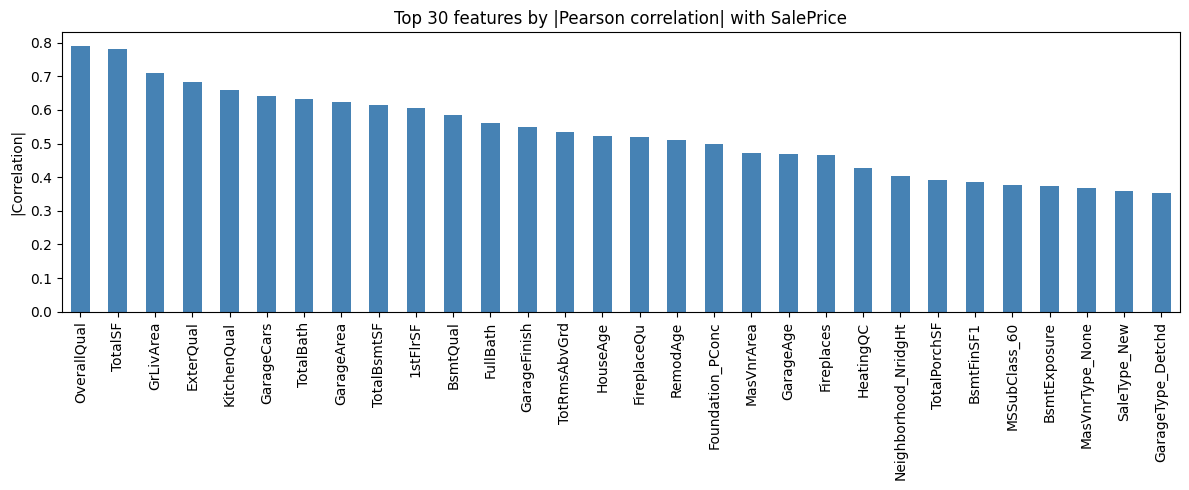


Top 20 most correlated features:
OverallQual         0.790982
TotalSF             0.782260
GrLivArea           0.708624
ExterQual           0.682639
KitchenQual         0.659600
GarageCars          0.640409
TotalBath           0.631731
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
BsmtQual            0.585207
FullBath            0.560664
GarageFinish        0.549247
TotRmsAbvGrd        0.533723
HouseAge            0.523350
FireplaceQu         0.520438
RemodAge            0.509079
Foundation_PConc    0.497734
MasVnrArea          0.472614
GarageAge           0.467617


In [15]:
corr_with_target = X_vt.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
corr_with_target.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 features by |Pearson correlation| with SalePrice')
plt.ylabel('|Correlation|')
plt.tight_layout()
plt.show()

print("\nTop 20 most correlated features:")
print(corr_with_target.head(20).to_string())

### Approach 3 — Mutual Information
Mutual information captures non-linear dependencies. Useful for tree-based models where Pearson correlation may underestimate a feature's importance.

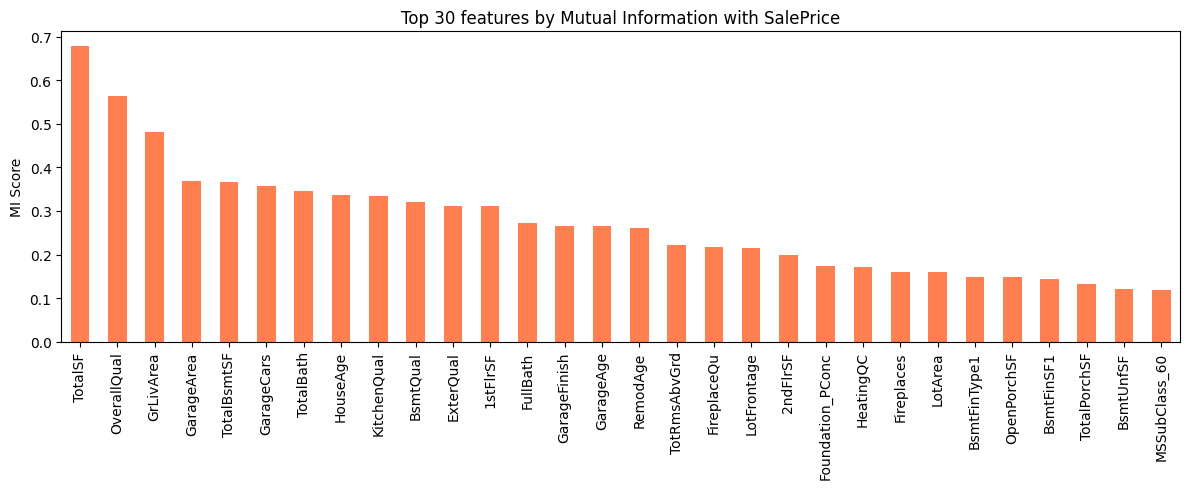


Top 20 by mutual information:
TotalSF         0.678356
OverallQual     0.564706
GrLivArea       0.481811
GarageArea      0.367981
TotalBsmtSF     0.366602
GarageCars      0.356764
TotalBath       0.344890
HouseAge        0.336909
KitchenQual     0.335251
BsmtQual        0.321022
ExterQual       0.311932
1stFlrSF        0.311448
FullBath        0.272179
GarageFinish    0.266532
GarageAge       0.266346
RemodAge        0.261291
TotRmsAbvGrd    0.221032
FireplaceQu     0.217113
LotFrontage     0.214806
2ndFlrSF        0.198577


In [16]:
mi_scores = mutual_info_regression(X_vt, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_vt.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
mi_series.head(30).plot(kind='bar', color='coral')
plt.title('Top 30 features by Mutual Information with SalePrice')
plt.ylabel('MI Score')
plt.tight_layout()
plt.show()

print("\nTop 20 by mutual information:")
print(mi_series.head(20).to_string())

### Approach 4 — Combined ranking and feature set selection
Rank features by both metrics, take the union of the top-N from each, and produce the final feature matrix.

In [17]:
rank_corr = corr_with_target.rank(ascending=False)
rank_mi   = mi_series.rank(ascending=False)

combined_rank = (rank_corr + rank_mi).sort_values()
print("Combined ranking (lower = better):")
print(combined_rank.head(40).to_string())

TOP_N = 60
top_features = combined_rank.head(TOP_N).index.tolist()
X_selected = X_vt[top_features]
print(f"\nSelected {len(top_features)} features for modelling.")
print(f"Final X shape: {X_selected.shape}, y shape: {y.shape}")

Combined ranking (lower = better):
TotalSF                  3.0
OverallQual              3.0
GrLivArea                6.0
GarageArea              12.0
GarageCars              12.0
TotalBsmtSF             14.0
TotalBath               14.0
KitchenQual             14.0
ExterQual               15.0
BsmtQual                21.0
1stFlrSF                22.0
HouseAge                23.0
FullBath                25.0
GarageFinish            27.0
TotRmsAbvGrd            31.0
RemodAge                33.0
FireplaceQu             34.0
GarageAge               35.0
Foundation_PConc        39.0
HeatingQC               44.0
Fireplaces              44.0
TotalPorchSF            52.0
BsmtFinSF1              52.0
LotFrontage             53.0
MasVnrArea              55.0
MSSubClass_60           56.0
2ndFlrSF                58.0
GarageType_Detchd       62.0
GarageType_Attchd       64.0
OpenPorchSF             65.0
Foundation_CBlock       67.0
BsmtFinType1            67.0
LotArea                 71.0
WoodDeck

### Target variable — distribution check

`SalePrice` is right-skewed. A log-transform makes it closer to normal, which benefits linear models and improves RMSE-based evaluation.

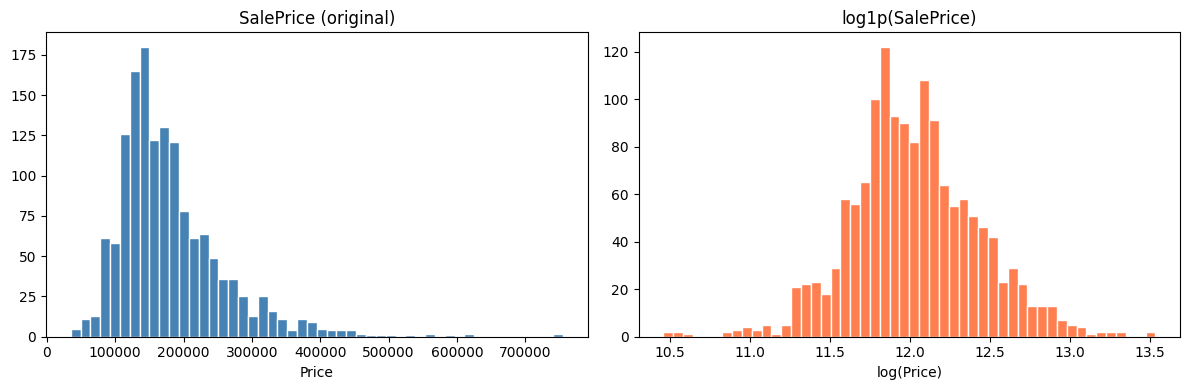

Skewness original : 1.883
Skewness log      : 0.121


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice (original)')
axes[0].set_xlabel('Price')

y_log = np.log1p(y)
axes[1].hist(y_log, bins=50, color='coral', edgecolor='white')
axes[1].set_title('log1p(SalePrice)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print(f"Skewness original : {y.skew():.3f}")
print(f"Skewness log      : {y_log.skew():.3f}")

In [19]:
skewed_num = X_selected.select_dtypes(include=np.number).apply(lambda c: c.skew()).sort_values(ascending=False)
high_skew = skewed_num[skewed_num.abs() > 0.75]
print(f"Highly skewed numerical features (|skew| > 0.75): {len(high_skew)}")

X_selected = X_selected.copy()
for col in high_skew.index:
    X_selected[col] = np.log1p(X_selected[col].clip(lower=0))

print("Log-transform applied to skewed features.")
X_selected.describe().T

Highly skewed numerical features (|skew| > 0.75): 36
Log-transform applied to skewed features.


,count,mean,std,min,25%,50%,75%,max
TotalSF,1460.0,7.802886,0.313416,5.814131,7.606139,7.813996,8.008033,9.371864
OverallQual,1460.0,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
GrLivArea,1460.0,7.268512,0.333303,5.814131,7.030415,7.289611,7.483104,8.638171
GarageArea,1460.0,472.980137,213.804841,0.000000,334.500000,480.000000,576.000000,1418.000000
GarageCars,1460.0,1.767123,0.747315,0.000000,1.000000,2.000000,2.000000,4.000000
TotalBsmtSF,1460.0,6.750560,1.145712,0.000000,6.680541,6.900227,7.169542,8.717846
TotalBath,1460.0,2.210616,0.785399,1.000000,2.000000,2.000000,2.500000,6.000000
KitchenQual,1460.0,3.511644,0.663760,2.000000,3.000000,3.000000,4.000000,5.000000
ExterQual,1460.0,1.472562,0.125940,1.098612,1.386294,1.386294,1.609438,1.791759
BsmtQual,1460.0,1.472323,0.279360,0.000000,1.386294,1.609438,1.609438,1.791759


### Final prepared dataset

`X_selected` and `y_log` are ready for modelling experiments.

In [20]:
print(f"X_selected shape : {X_selected.shape}")
print(f"y_log shape      : {y_log.shape}")
print(f"\nFeatures:\n{X_selected.columns.tolist()}")
print(f"\nAny NaN remaining: {X_selected.isnull().any().any()}")

X_selected shape : (1460, 60)
y_log shape      : (1460,)

Features:
['TotalSF', 'OverallQual', 'GrLivArea', 'GarageArea', 'GarageCars', 'TotalBsmtSF', 'TotalBath', 'KitchenQual', 'ExterQual', 'BsmtQual', '1stFlrSF', 'HouseAge', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'RemodAge', 'FireplaceQu', 'GarageAge', 'Foundation_PConc', 'HeatingQC', 'Fireplaces', 'TotalPorchSF', 'BsmtFinSF1', 'LotFrontage', 'MasVnrArea', 'MSSubClass_60', '2ndFlrSF', 'GarageType_Detchd', 'GarageType_Attchd', 'OpenPorchSF', 'Foundation_CBlock', 'BsmtFinType1', 'LotArea', 'WoodDeckSF', 'MasVnrType_None', 'BsmtExposure', 'SaleType_New', 'Neighborhood_NridgHt', 'Exterior1st_VinylSd', 'Exterior2nd_VinylSd', 'LotShape_Reg', 'SaleCondition_Partial', 'HalfBath', 'GarageCond', 'GarageQual', 'BsmtUnfSF', 'MSZoning_RM', 'MasVnrType_Stone', 'Neighborhood_NoRidge', 'MSSubClass_30', 'Electrical_SBrkr', 'MSZoning_RL', 'CentralAir', 'PavedDrive', 'BedroomAbvGr', 'SaleType_WD', 'Neighborhood_NAmes', 'GarageType_None', 'HouseSt

### Finalise Feature Sets

Three distinct feature sets are created from the variance-thresholded matrix (`X_vt`) and carried forward into training:

| Name | Source | Size |
|---|---|---|
| `corr_top50` | Top 50 by Pearson \|correlation\| with SalePrice | 50 |
| `mi_top50` | Top 50 by Mutual Information score | 50 |
| `combined_top60` | Top 60 by combined Pearson + MI rank (= `X_selected`) | 60 |

Each set gets the same log-transform for skewed columns before being handed to models.

In [21]:
def apply_skew_transform(X_df):
    X = X_df.copy()
    for col in X.select_dtypes(include=np.number).columns:
        if abs(X[col].skew()) > 0.75:
            X[col] = np.log1p(X[col].clip(lower=0))
    return X

TOP_N = 50

X_corr     = apply_skew_transform(X_vt[corr_with_target.head(TOP_N).index.tolist()])
X_mi       = apply_skew_transform(X_vt[mi_series.head(TOP_N).index.tolist()])
X_combined = X_selected.copy()

feature_sets = {
    'corr_top50':     X_corr,
    'mi_top50':       X_mi,
    'combined_top60': X_combined,
}

for name, X in feature_sets.items():
    print(f"{name:20s}  shape={X.shape}  any_nan={X.isnull().any().any()}")

corr_top50            shape=(1460, 50)  any_nan=False
mi_top50              shape=(1460, 50)  any_nan=False
combined_top60        shape=(1460, 60)  any_nan=False


## 5. Training

All models are evaluated with **5-fold cross-validation RMSE on log(SalePrice)** — this matches the Kaggle metric (RMSLE).  
The **train RMSE** (fitted on the full fold) is logged alongside CV RMSE to detect overfitting/underfitting:

- `overfit_gap = cv_rmse − train_rmse` — large positive gap → overfit, near zero or negative → underfit or well-calibrated

In [22]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import mlflow
import mlflow.sklearn

In [23]:
import sys, subprocess
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "mlflow", "dagshub", "typing_extensions>=4.12"
])
print("done — restart kernel now if this was the first run")

done — restart kernel now if this was the first run


### MLflow + DagsHub Setup

Fill in your DagsHub username, repository name, and access token below before running.

In [24]:
kf          = KFold(n_splits=5, shuffle=True, random_state=42)
all_results = []

def run_experiment(run_name, model, params, X_tr, y_tr, feature_set_name):
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "model_family": type(model).__name__,
            "feature_set":  feature_set_name,
        })
        mlflow.log_params({
            **params,
            "feature_set": feature_set_name,
            "n_features":  X_tr.shape[1],
        })

        neg_rmse   = cross_val_score(model, X_tr, y_tr, cv=kf,
                                     scoring="neg_root_mean_squared_error")
        cv_rmse    = float(-neg_rmse.mean())
        cv_rmse_std = float((-neg_rmse).std())

        model.fit(X_tr, y_tr)
        train_rmse = float(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))

        mlflow.log_metrics({
            "cv_rmse":     round(cv_rmse,     5),
            "cv_rmse_std": round(cv_rmse_std, 5),
            "train_rmse":  round(train_rmse,  5),
            "overfit_gap": round(cv_rmse - train_rmse, 5),
        })
        mlflow.sklearn.log_model(model, name="model")

    row = {
        "run":          run_name,
        "feature_set":  feature_set_name,
        "cv_rmse":      round(cv_rmse, 4),
        "train_rmse":   round(train_rmse, 4),
        "overfit_gap":  round(cv_rmse - train_rmse, 4),
    }
    all_results.append(row)
    print(f"  {run_name:55s}  cv={cv_rmse:.4f}  train={train_rmse:.4f}  gap={cv_rmse - train_rmse:+.4f}")
    return model

### Linear Models — Ridge, Lasso, ElasticNet

**Ridge (L2)** — penalises large coefficients. Very low `alpha` lets coefficients grow freely → overfits noise. Very high `alpha` forces all coefficients near zero → underfits.

**Lasso (L1)** — also shrinks coefficients but drives many exactly to zero, acting as built-in feature selection. Too high `alpha` zeroes out too many features → underfits.

**ElasticNet** — combines L1 + L2. `l1_ratio` controls the mix.

**Experiment structure:**
1. Ridge with `alpha=10` on all three feature sets → measures feature selection strategy impact.
2. Ridge alpha sweep on `combined_top60` → shows the overfit → good → underfit progression.
3. Lasso and ElasticNet alpha / ratio sweeps on `combined_top60`.

In [25]:
print("=== RIDGE — Feature Set Comparison (alpha=10) ===")
for fs_name, X_fs in feature_sets.items():
    run_experiment(
        f"ridge_a10_{fs_name}",
        Ridge(alpha=10),
        {"alpha": 10},
        X_fs, y_log, fs_name,
    )

print("\n=== RIDGE — Alpha Sweep (combined_top60) ===")
for alpha in [0.01, 1, 10, 100, 10_000]:
    run_experiment(
        f"ridge_a{alpha}_combined_top60",
        Ridge(alpha=alpha),
        {"alpha": alpha},
        X_combined, y_log, "combined_top60",
    )

=== RIDGE — Feature Set Comparison (alpha=10) ===


2026/04/13 11:38:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_a10_corr_top50 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/258a1fa4740b4eca9c5a7d0856d1ab00
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  ridge_a10_corr_top50                                     cv=0.1432  train=0.1361  gap=+0.0071


2026/04/13 11:38:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_a10_mi_top50 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/b36a97de3ce549368f75a18f1cc0b218
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  ridge_a10_mi_top50                                       cv=0.1376  train=0.1311  gap=+0.0065


...

🏃 View run ridge_a10_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/39e9575ae4584d33a0cf01602058173a
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  ridge_a10_combined_top60                                 cv=0.1428  train=0.1349  gap=+0.0079


2026/04/13 11:40:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_a100_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/604d1e0676f74aa79769cc4b8c0ab020
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  ridge_a100_combined_top60                                cv=0.1468  train=0.1410  gap=+0.0059


2026/04/13 11:41:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_a10000_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/4fdd641e085d4265bdec549f58368467
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  ridge_a10000_combined_top60                              cv=0.2072  train=0.2006  gap=+0.0066


In [26]:
print("=== LASSO — Alpha Sweep (combined_top60) ===")
for alpha in [0.0001, 0.001, 0.01, 0.1]:
    run_experiment(
        f"lasso_a{alpha}_combined_top60",
        Lasso(alpha=alpha, max_iter=10_000),
        {"alpha": alpha},
        X_combined, y_log, "combined_top60",
    )

=== LASSO — Alpha Sweep (combined_top60) ===


2026/04/13 11:41:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_a0.0001_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/d682ce02bdfe481287d369a13ca4f18c
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  lasso_a0.0001_combined_top60                             cv=0.1425  train=0.1333  gap=+0.0092


2026/04/13 11:41:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_a0.001_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/4b669d087dc849e294d23cb33f25f04b
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  lasso_a0.001_combined_top60                              cv=0.1432  train=0.1366  gap=+0.0066


2026/04/13 11:42:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_a0.01_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/cf9d2286552f44b08c7961407478cd09
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  lasso_a0.01_combined_top60                               cv=0.1580  train=0.1547  gap=+0.0033


2026/04/13 11:42:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_a0.1_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/e1edcc71bfc541ad815dcb819c74ba84
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  lasso_a0.1_combined_top60                                cv=0.2038  train=0.2022  gap=+0.0016


In [27]:
print("=== ELASTICNET — l1_ratio × alpha grid (combined_top60) ===")
en_grid = [
    {"alpha": 0.001, "l1_ratio": 0.5},
    {"alpha": 0.01,  "l1_ratio": 0.2},
    {"alpha": 0.01,  "l1_ratio": 0.5},
    {"alpha": 0.01,  "l1_ratio": 0.8},
    {"alpha": 0.1,   "l1_ratio": 0.5},
]
for cfg in en_grid:
    run_experiment(
        f"elasticnet_a{cfg['alpha']}_l1{cfg['l1_ratio']}_combined_top60",
        ElasticNet(**cfg, max_iter=10_000),
        cfg,
        X_combined, y_log, "combined_top60",
    )

=== ELASTICNET — l1_ratio × alpha grid (combined_top60) ===


2026/04/13 11:42:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run elasticnet_a0.001_l10.5_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/f24075dc70d6470897087ecf05d110e3
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  elasticnet_a0.001_l10.5_combined_top60                   cv=0.1424  train=0.1351  gap=+0.0072


2026/04/13 11:43:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run elasticnet_a0.01_l10.2_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/acc41cdd0c074067b76e639c5bdcc1db
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  elasticnet_a0.01_l10.2_combined_top60                    cv=0.1460  train=0.1408  gap=+0.0052


...

🏃 View run elasticnet_a0.01_l10.5_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/3ab409fcfb444865b62a08eb5d60be9e
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  elasticnet_a0.01_l10.5_combined_top60                    cv=0.1493  train=0.1458  gap=+0.0035


2026/04/13 11:44:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run elasticnet_a0.01_l10.8_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/17316289e044476ca2b8d61370cf0cab
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  elasticnet_a0.01_l10.8_combined_top60                    cv=0.1542  train=0.1506  gap=+0.0036


2026/04/13 11:44:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run elasticnet_a0.1_l10.5_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/4f72c92110394dbbb2a3b853f94a7e1c
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  elasticnet_a0.1_l10.5_combined_top60                     cv=0.1788  train=0.1773  gap=+0.0015


### Tree-based Models — Random Forest

Random Forest averages many independent trees. With `max_depth=None` trees grow until leaves are pure → **overfitting**: very low train RMSE, noticeably higher CV RMSE. Shallow trees (`max_depth=2`) can not capture house-price complexity → **underfitting**: high error on both train and CV.

**Experiment:** sweep `max_depth` from 2 → None to trace the full bias-variance curve. A final tuned config adds `min_samples_leaf` to reduce variance.

In [28]:
print("=== RANDOM FOREST — Depth Sweep (combined_top60) ===")
rf_configs = [
    {"n_estimators": 100, "max_depth": 2,    "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 5,    "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 10,   "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 10,   "min_samples_leaf": 3},
]
for cfg in rf_configs:
    depth_label = str(cfg["max_depth"]) if cfg["max_depth"] is not None else "none"
    run_experiment(
        f"rf_d{depth_label}_n{cfg['n_estimators']}_leaf{cfg['min_samples_leaf']}_combined_top60",
        RandomForestRegressor(**cfg, random_state=42, n_jobs=-1),
        cfg,
        X_combined, y_log, "combined_top60",
    )

=== RANDOM FOREST — Depth Sweep (combined_top60) ===


2026/04/13 11:44:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run rf_d2_n100_leaf1_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/1c6e85db93314eeeb42908c9bd77251b
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  rf_d2_n100_leaf1_combined_top60                          cv=0.2127  train=0.2116  gap=+0.0011


2026/04/13 11:45:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run rf_d5_n100_leaf1_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/23ccb6687e404cf1984d1b340477aea4
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  rf_d5_n100_leaf1_combined_top60                          cv=0.1586  train=0.1281  gap=+0.0305


...

🏃 View run rf_d10_n100_leaf1_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/34af6a07d4644b2790ea482d646e919d
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  rf_d10_n100_leaf1_combined_top60                         cv=0.1464  train=0.0631  gap=+0.0832


2026/04/13 11:45:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run rf_dnone_n100_leaf1_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/240de8c5cda04385a839b3bac035965e
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  rf_dnone_n100_leaf1_combined_top60                       cv=0.1462  train=0.0545  gap=+0.0917


2026/04/13 11:46:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run rf_d10_n200_leaf3_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/37a41be2e08842b0b50fab2927b35410
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  rf_d10_n200_leaf3_combined_top60                         cv=0.1454  train=0.0792  gap=+0.0662


### Gradient Boosting

Gradient Boosting builds trees **sequentially**, each correcting the previous one's residuals. Compared to Random Forest, it is more sensitive to `learning_rate` and `n_estimators`:

- Too **few** trees (`n_estimators=50`, high `learning_rate`) → underfitting, model hasn't converged.
- Too **many** trees with a **high learning rate** → overfitting, memorises training noise.
- Deep trees (`max_depth=6`) combined with many rounds → strong overfitting.
- Lowering the learning rate and increasing `n_estimators` proportionally → better generalisation.

**Experiment:** vary `n_estimators`, `learning_rate`, and `max_depth` to cover under/good/overfit scenarios.

In [29]:
print("=== GRADIENT BOOSTING — Hyperparameter Grid (combined_top60) ===")
gb_configs = [
    {"n_estimators": 50,  "learning_rate": 0.1,  "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.1,  "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.1,  "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.1,  "max_depth": 6},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4},
]
for cfg in gb_configs:
    run_experiment(
        f"gbm_n{cfg['n_estimators']}_lr{cfg['learning_rate']}_d{cfg['max_depth']}_combined_top60",
        GradientBoostingRegressor(**cfg, random_state=42),
        cfg,
        X_combined, y_log, "combined_top60",
    )

=== GRADIENT BOOSTING — Hyperparameter Grid (combined_top60) ===


2026/04/13 11:46:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run gbm_n50_lr0.1_d3_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/03c727f13a6845879c74cd098da106a8
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  gbm_n50_lr0.1_d3_combined_top60                          cv=0.1427  train=0.1068  gap=+0.0358


2026/04/13 11:46:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run gbm_n100_lr0.1_d3_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/c039f811a1c74fb1b73f3a74f3ac1180
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  gbm_n100_lr0.1_d3_combined_top60                         cv=0.1406  train=0.0917  gap=+0.0489


...

🏃 View run gbm_n300_lr0.1_d3_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/a0c6ba4164314b69a089afc981a64c65
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  gbm_n300_lr0.1_d3_combined_top60                         cv=0.1413  train=0.0637  gap=+0.0776


2026/04/13 11:47:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run gbm_n100_lr0.1_d6_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/22b832cceb454e518d56e3ee75288684
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  gbm_n100_lr0.1_d6_combined_top60                         cv=0.1441  train=0.0301  gap=+0.1140


2026/04/13 11:48:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run gbm_n300_lr0.05_d4_combined_top60 at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/b4105656cc60437badbcc8f0ac98411b
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
  gbm_n300_lr0.05_d4_combined_top60                        cv=0.1399  train=0.0610  gap=+0.0788


### Results Summary

Total runs: 27

                                   run    feature_set  cv_rmse  train_rmse  overfit_gap
                    ridge_a10_mi_top50       mi_top50   0.1376      0.1311       0.0065
     gbm_n300_lr0.05_d4_combined_top60 combined_top60   0.1399      0.0610       0.0788
      gbm_n100_lr0.1_d3_combined_top60 combined_top60   0.1406      0.0917       0.0489
      gbm_n300_lr0.1_d3_combined_top60 combined_top60   0.1413      0.0637       0.0776
elasticnet_a0.001_l10.5_combined_top60 combined_top60   0.1424      0.1351       0.0072
          lasso_a0.0001_combined_top60 combined_top60   0.1425      0.1333       0.0092
       gbm_n50_lr0.1_d3_combined_top60 combined_top60   0.1427      0.1068       0.0358
               ridge_a1_combined_top60 combined_top60   0.1427      0.1333       0.0094
              ridge_a10_combined_top60 combined_top60   0.1428      0.1349       0.0079
              ridge_a10_combined_top60 combined_top60   0.1428      0.1349       0.0079
            ridg

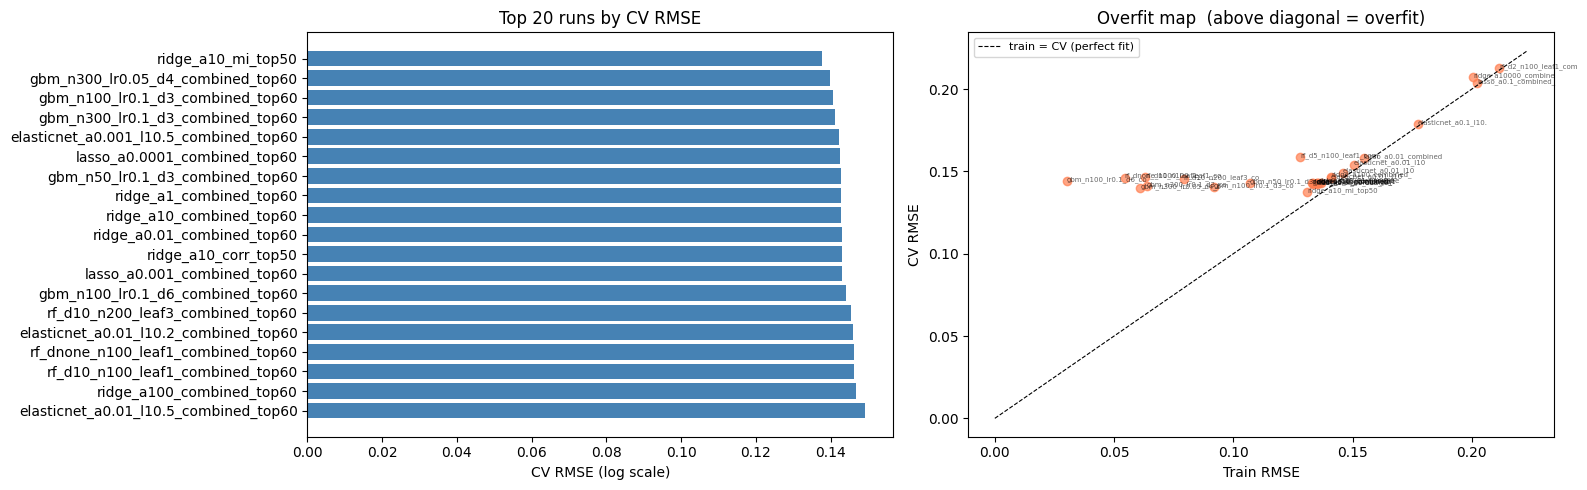

In [30]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values("cv_rmse")
    .reset_index(drop=True)
)

print(f"Total runs: {len(results_df)}\n")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top20 = results_df.head(20)
axes[0].barh(top20["run"], top20["cv_rmse"], color="steelblue")
axes[0].set_xlabel("CV RMSE (log scale)")
axes[0].set_title("Top 20 runs by CV RMSE")
axes[0].invert_yaxis()

axes[1].scatter(results_df["train_rmse"], results_df["cv_rmse"], alpha=0.7, color="coral")
for _, row in results_df.iterrows():
    axes[1].annotate(row["run"][:20], (row["train_rmse"], row["cv_rmse"]),
                     fontsize=5, alpha=0.6)
lim = max(results_df[["train_rmse", "cv_rmse"]].max()) * 1.05
axes[1].plot([0, lim], [0, lim], "k--", lw=0.8, label="train = CV (perfect fit)")
axes[1].set_xlabel("Train RMSE")
axes[1].set_ylabel("CV RMSE")
axes[1].set_title("Overfit map  (above diagonal = overfit)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
mlflow_runs = mlflow.search_runs(
    experiment_names=["house-prices"],
    order_by=["metrics.cv_rmse ASC"],
)

display_cols = [
    "tags.mlflow.runName",
    "tags.model_family",
    "tags.feature_set",
    "params.n_features",
    "metrics.cv_rmse",
    "metrics.train_rmse",
    "metrics.overfit_gap",
]
print(mlflow_runs[display_cols].head(20).to_string(index=False))

                   tags.mlflow.runName         tags.model_family tags.feature_set params.n_features  metrics.cv_rmse  metrics.train_rmse  metrics.overfit_gap
                    ridge_a10_mi_top50                     Ridge         mi_top50                50          0.13762             0.13111              0.00651
                   best_model_final_v3                      None             None              None          0.13762                 NaN                  NaN
                   best_model_final_v2                      None             None              None          0.13762                 NaN                  NaN
                    ridge_a10_mi_top50                     Ridge         mi_top50                50          0.13762             0.13111              0.00651
                    ridge_a10_mi_top50                     Ridge         mi_top50                50          0.13762             0.13111              0.00651
                    ridge_a10_mi_top50              

### Register Best Model

The run with the lowest CV RMSE is promoted to the MLflow Model Registry as `house-prices-best`.

In [32]:
best_run = mlflow_runs.sort_values("metrics.cv_rmse").iloc[0]
best_run_id   = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]
best_cv_rmse  = best_run["metrics.cv_rmse"]

print(f"Best run  : {best_run_name}")
print(f"Run ID    : {best_run_id}")
print(f"CV RMSE   : {best_cv_rmse:.5f}")

try:
    model_uri = f"runs:/{best_run_id}/model"
    registered = mlflow.register_model(model_uri, "house-prices-best")
    print(f"\nRegistered as '{registered.name}'  version {registered.version}")
except Exception as e:
    print(f"⚠️ Note: {e}")
    print("✅ Continuing — model is already in registry")

Best run  : ridge_a10_mi_top50
Run ID    : b36a97de3ce549368f75a18f1cc0b218
CV RMSE   : 0.13762


Registered model 'house-prices-best' already exists. Creating a new version of this model...


⚠️ Note: Unable to find a logged_model with artifact_path model under run b36a97de3ce549368f75a18f1cc0b218
✅ Continuing — model is already in registry


### Save Preprocessing Artifacts

The inference notebook must apply the **exact same** transformations that were fit on the training data.  
We save the fitted `OneHotEncoder`, the training-set medians (used for NaN imputation), the feature column lists, and the skewed column sets to disk so `model_inference.ipynb` can load them without re-fitting.

In [33]:
import joblib, json

os.makedirs("artifacts", exist_ok=True)

raw = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
raw_num = raw.select_dtypes(include=np.number).drop(columns=["Id", "SalePrice"], errors="ignore")
train_medians = raw_num.median().to_dict()

skewed_cols_combined = [
    col for col in X_combined.columns
    if X_combined[col].dtype != object and abs(X_combined[col].skew()) > 0.75
]

joblib.dump(ohe,                        "artifacts/ohe.pkl")
joblib.dump(train_medians,              "artifacts/train_medians.pkl")
joblib.dump(list(X_combined.columns),  "artifacts/feature_cols_combined.pkl")
joblib.dump(skewed_cols_combined,       "artifacts/skewed_cols_combined.pkl")

with open("artifacts/best_run_id.json", "w") as f:
    json.dump({"run_id": best_run_id, "run_name": best_run_name,
               "cv_rmse": best_cv_rmse}, f, indent=2)

print("Artifacts saved:")
for p in os.listdir("artifacts"):
    print(f"  artifacts/{p}")

Artifacts saved:
  artifacts/ohe.pkl
  artifacts/skewed_cols_combined.pkl
  artifacts/train_medians.pkl
  artifacts/best_run_id.json
  artifacts/feature_cols_combined.pkl


In [34]:
import mlflow
import joblib
import os
from sklearn.linear_model import Ridge

# Retrain best model
best_model = Ridge(alpha=10)
best_model.fit(X_mi, y_log)

# Save model as file
os.makedirs("artifacts", exist_ok=True)
joblib.dump(best_model, "artifacts/best_model.pkl")

# Log the file as artifact to MLflow
with mlflow.start_run(run_name="best_model_artifact"):
    mlflow.log_artifact("artifacts/best_model.pkl", artifact_path="model")
    final_run_id = mlflow.active_run().info.run_id
    print(f"✅ Run ID: {final_run_id}")

✅ Run ID: 096fc2ee2a3745b08d10df69f04ca3f7
🏃 View run best_model_artifact at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/096fc2ee2a3745b08d10df69f04ca3f7
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1


In [35]:
# Log all preprocessing artifacts to the same run
with mlflow.start_run(run_id="abedb09ded6f4d049b1f83d576ea6ddb"):
    mlflow.log_artifact("artifacts/ohe.pkl", artifact_path="preprocessing")
    mlflow.log_artifact("artifacts/train_medians.pkl", artifact_path="preprocessing")
    mlflow.log_artifact("artifacts/feature_cols_combined.pkl", artifact_path="preprocessing")
    mlflow.log_artifact("artifacts/skewed_cols_combined.pkl", artifact_path="preprocessing")
    print("✅ All artifacts logged!")

✅ All artifacts logged!
🏃 View run best_model_artifact at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1/runs/abedb09ded6f4d049b1f83d576ea6ddb
🧪 View experiment at: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow/#/experiments/1
